In [11]:
# Import necessary libraries
import pandas as pd  # For data manipulation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split  # For splitting dataset
from sklearn.ensemble import RandomForestClassifier  # Machine learning model
from sklearn.metrics import accuracy_score  # To evaluate model performance
from sklearn.preprocessing import LabelEncoder  # To convert categorical to numeric

In [12]:
# Load the dataset
df = pd.read_csv("titanic.csv")

In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [14]:
# Drop columns that are unlikely to help with predictions
# 'PassengerId', 'Name', 'Ticket', and 'Cabin' contain too many unique/missing values or are irrelevant
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [15]:
# Fill missing values in 'Age' column with the median age
df['Age'].fillna(df['Age'].median(), inplace=True)

<ipython-input-15-6c8708158d5e>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [16]:
# Fill missing values in 'Embarked' with the most frequent (mode) value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Convert categorical variables to numeric using Label Encoding
le = LabelEncoder()

<ipython-input-16-7a709339fa96>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [17]:
# Encode 'Sex' column: male becomes 1, female becomes 0
df['Sex'] = le.fit_transform(df['Sex'])

# Encode 'Embarked' column: C, Q, S become 0, 1, 2 (or similar depending on mapping)
df['Embarked'] = le.fit_transform(df['Embarked'])

# Separate features (X) and target (y)
X = df.drop('Survived', axis=1)  # Features used to make predictions
y = df['Survived']  # Target variable we want to predict

In [18]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest classifier with 100 trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
# Use the trained model to make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model by comparing predictions to the actual test labels
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


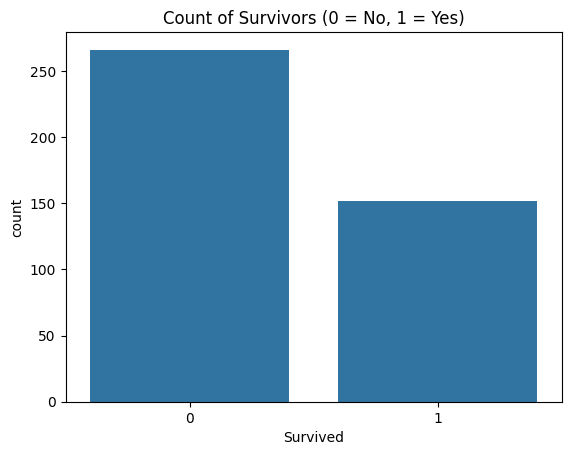

In [20]:
# survival count plot
sns.countplot(x='Survived', data=df)
plt.title('Count of Survivors (0 = No, 1 = Yes)')
plt.show()


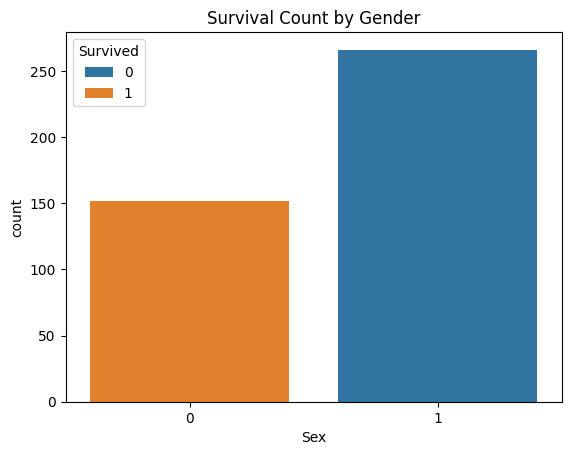

In [21]:
# Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Gender')
plt.show()


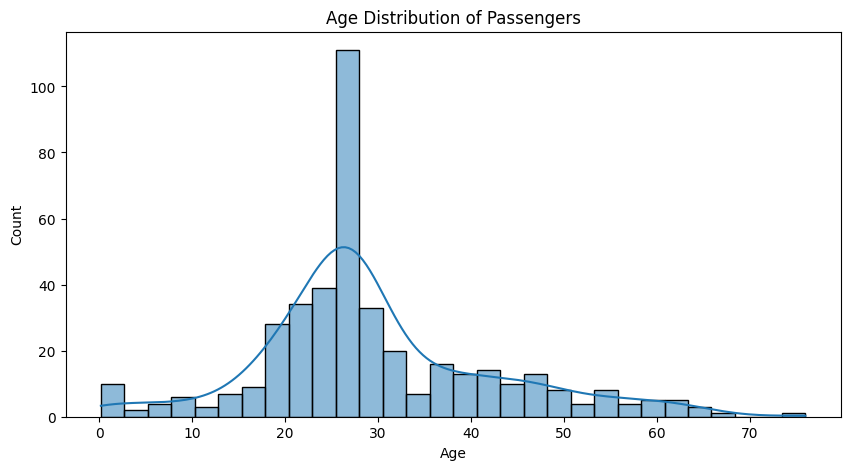

In [22]:
# Age distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], kde=True, bins=30)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


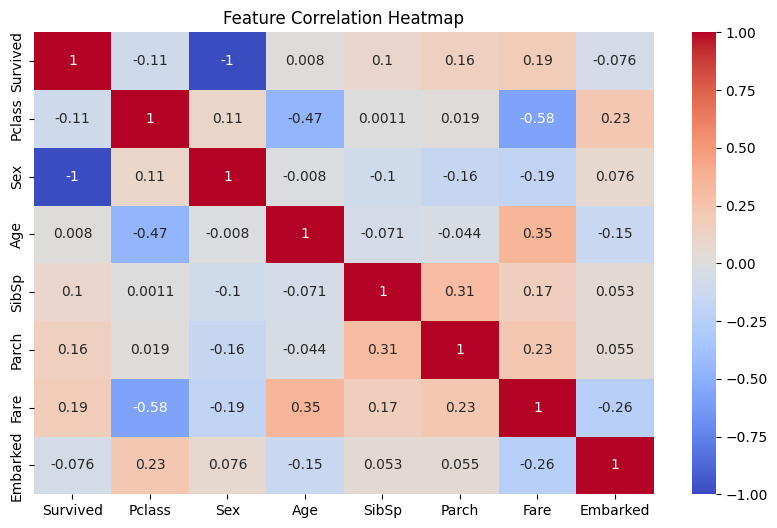

In [23]:
# Heatmap of correlations
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()
